Missing Values:

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:

             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

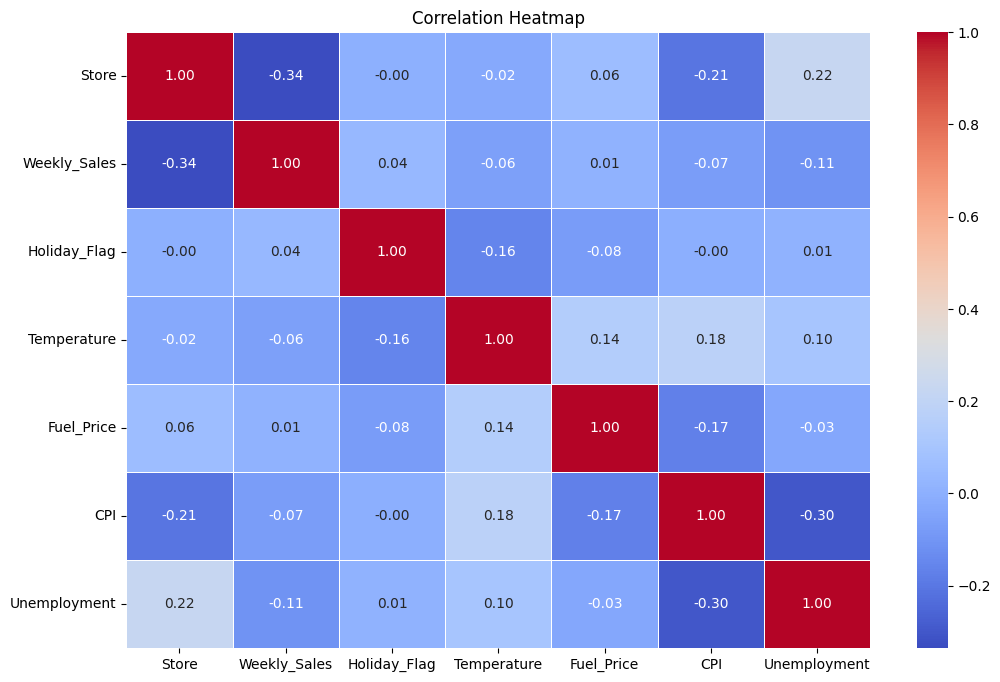

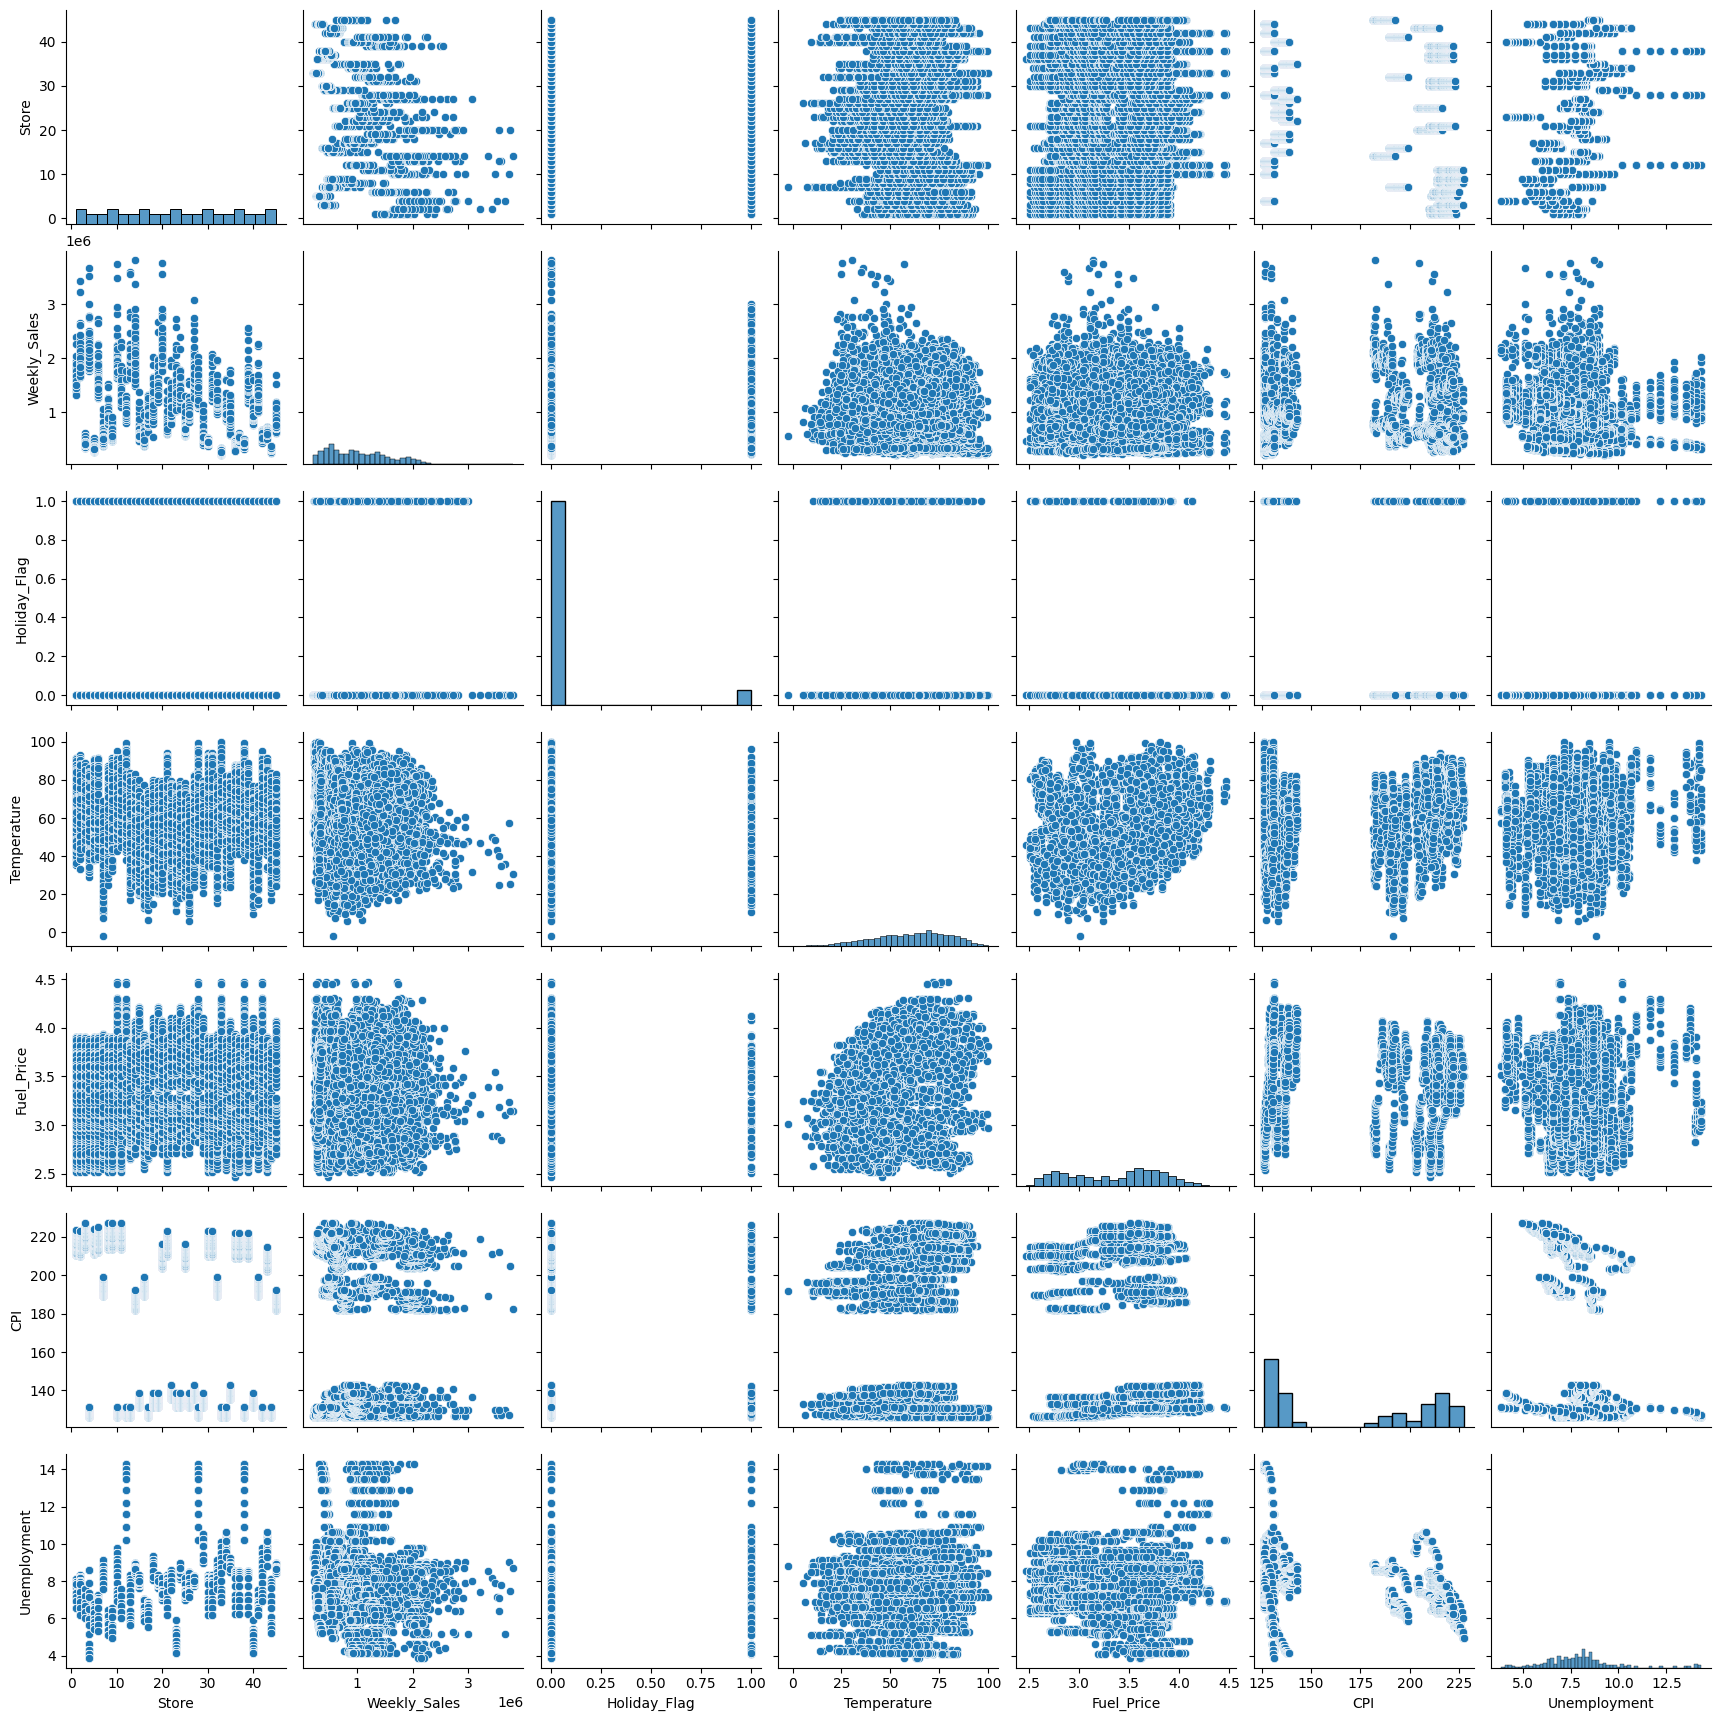

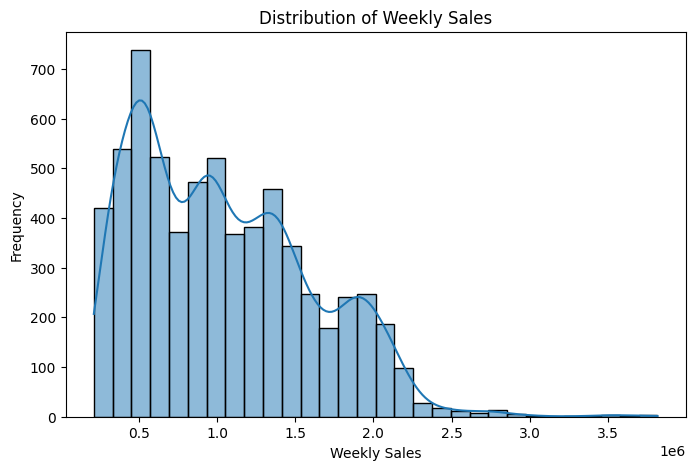

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n")
print(df.describe())

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot (all numeric columns)
sns.pairplot(numeric_df)
plt.show()

# Histogram of Weekly_Sales (change column name if needed)
if 'Weekly_Sales' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['Weekly_Sales'], bins=30, kde=True)
    plt.title("Distribution of Weekly Sales")
    plt.xlabel("Weekly Sales")
    plt.ylabel("Frequency")
    plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Target column
y = numeric_df['Weekly_Sales']

# Features
X = numeric_df.drop(columns=['Weekly_Sales'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1481
RMSE: 523884.7405


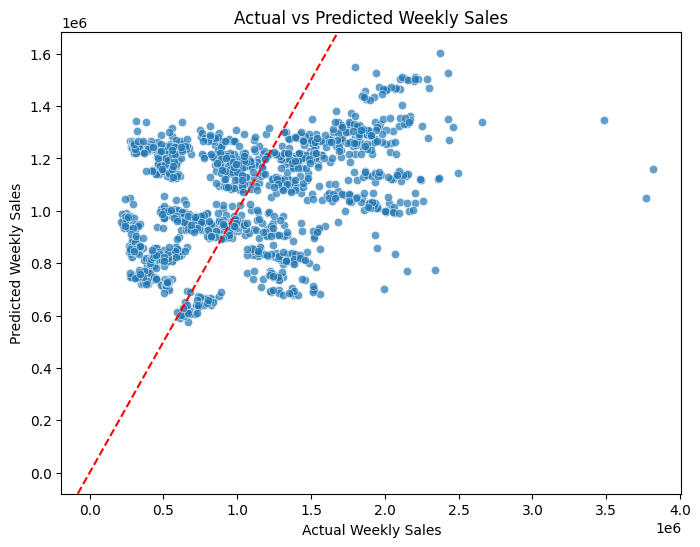

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")

# Perfect prediction line
plt.axline((0, 0), slope=1, color='red', linestyle='--')

plt.show()

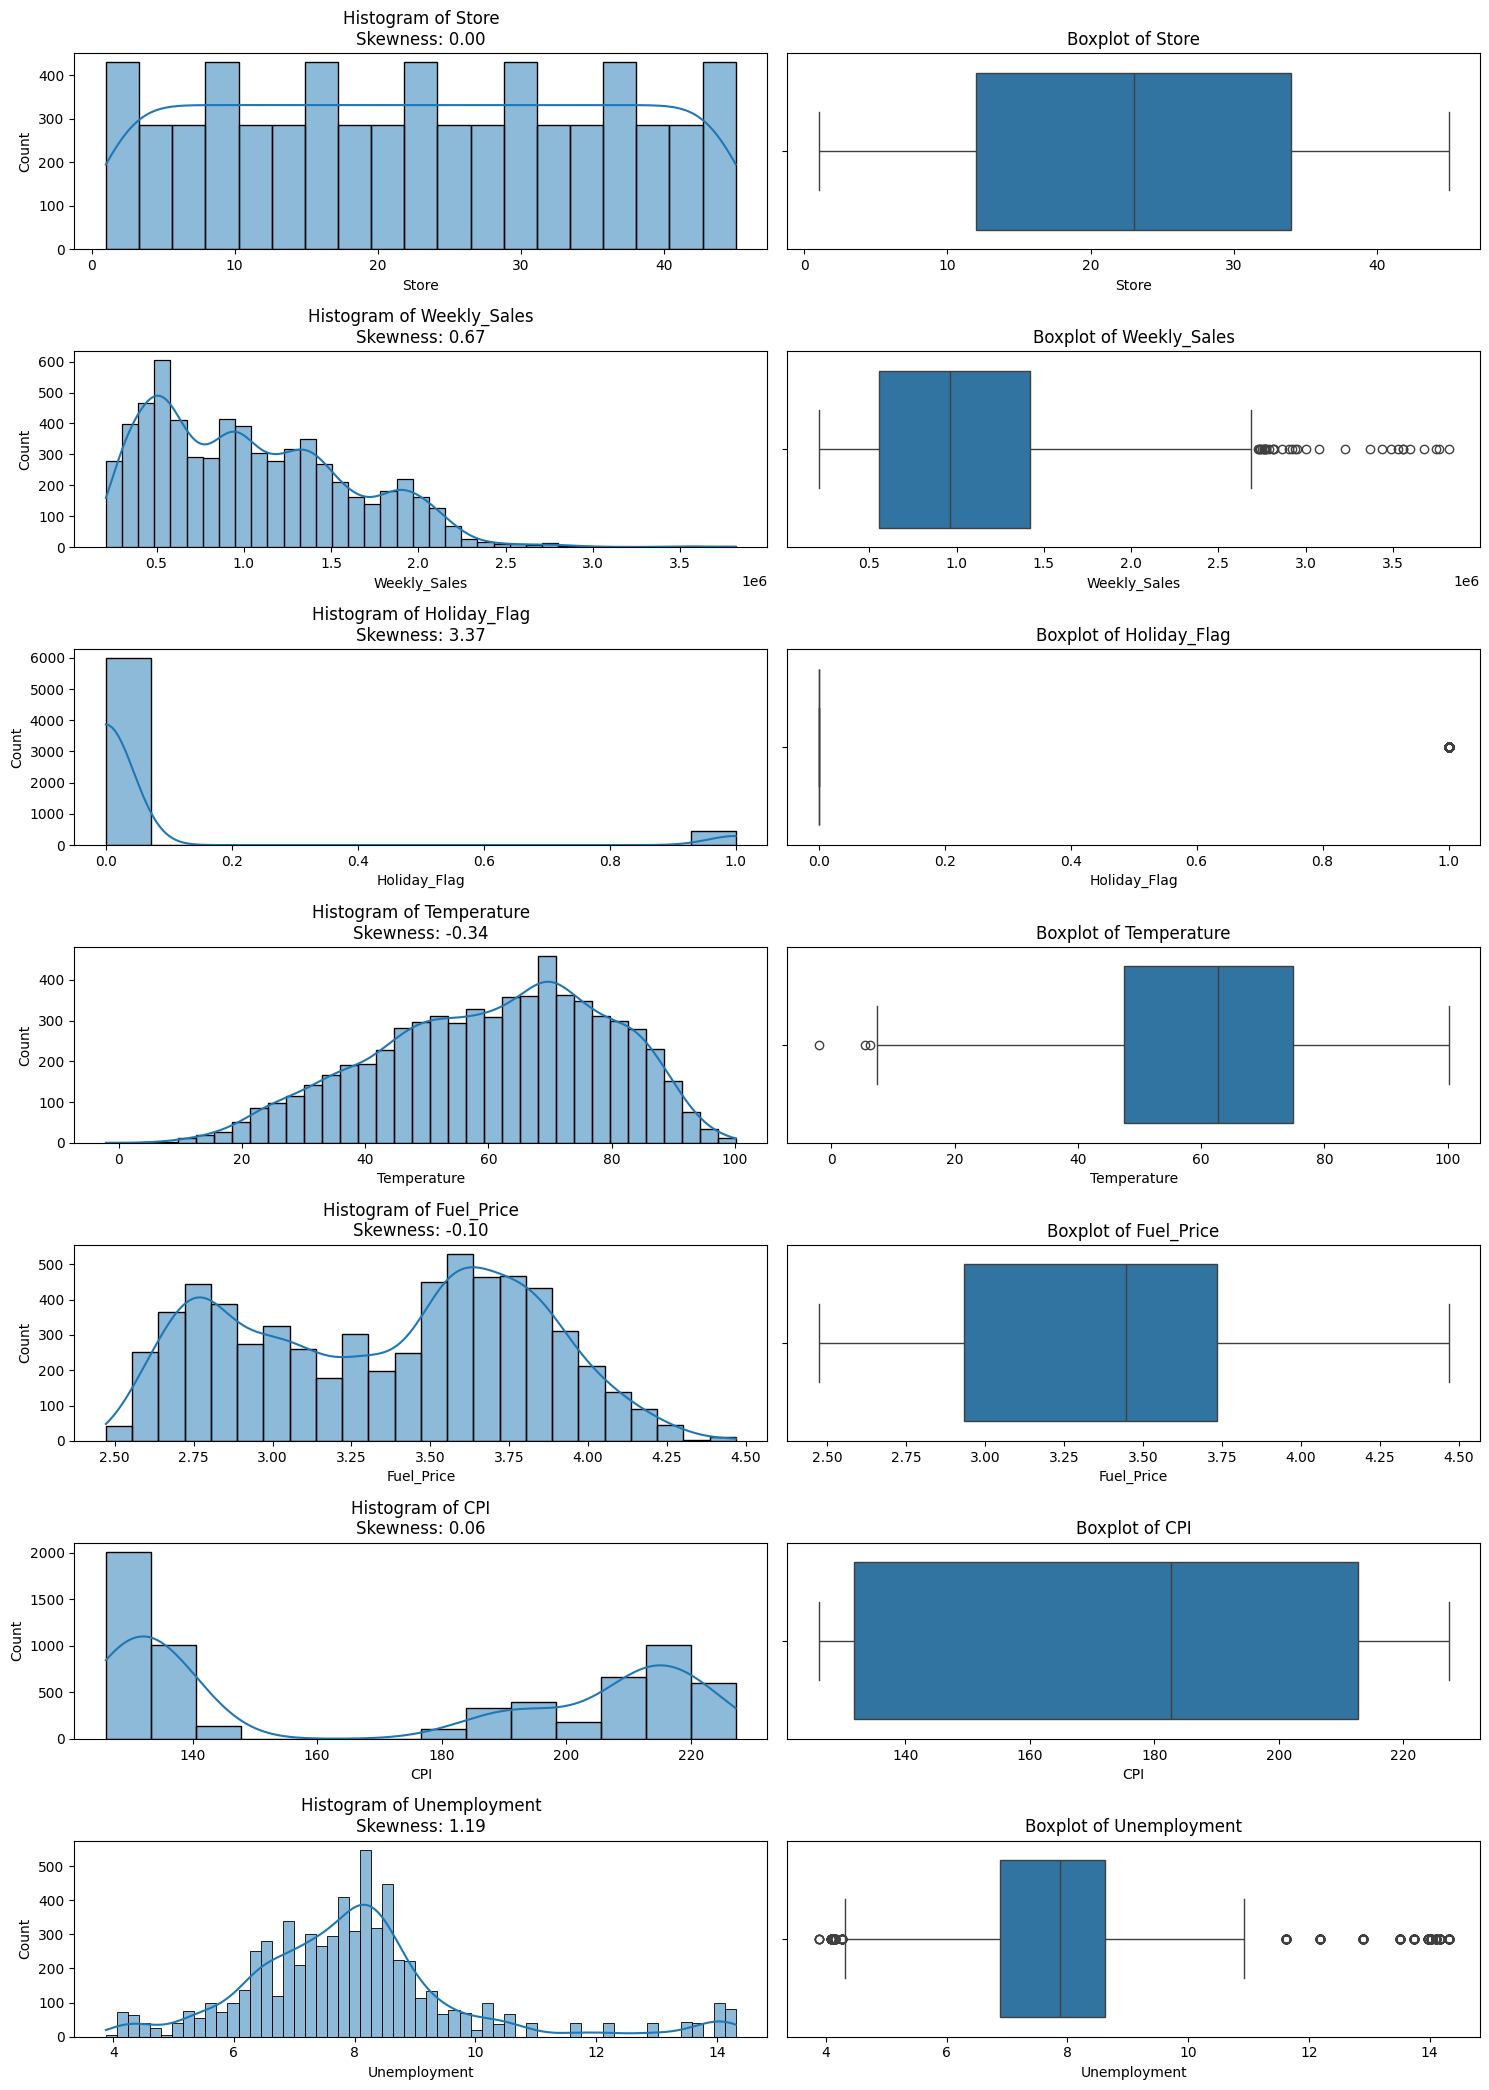

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate skewness
skewness = numeric_df.skew()

num_cols = len(numeric_df.columns)

plt.figure(figsize=(15, num_cols * 3))

for i, col in enumerate(numeric_df.columns):
    plt.subplot(num_cols, 2, 2*i + 1)
    sns.histplot(numeric_df[col], kde=True)
    plt.title(f'Histogram of {col}\nSkewness: {skewness[col]:.2f}')

    plt.subplot(num_cols, 2, 2*i + 2)
    sns.boxplot(x=numeric_df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate skewness
skewed_cols = numeric_df.skew().abs()

# Highly skewed columns (|skewness| > 1)
highly_skewed = skewed_cols[skewed_cols > 1].index

# Less skewed columns (|skewness| <= 1)
less_skewed = skewed_cols[skewed_cols <= 1].index

print("Highly Skewed Columns:")
print(list(highly_skewed))

print("\nLess Skewed Columns:")
print(list(less_skewed))

Highly Skewed Columns:
['Holiday_Flag', 'Unemployment']

Less Skewed Columns:
['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']


In [10]:
df[highly_skewed]=df[highly_skewed].apply(lambda x: np.log1p(x))

In [13]:
from sklearn.preprocessing import PowerTransformer

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# True negatively skewed columns
negative_skewed = numeric_df.skew()[numeric_df.skew() < 0].index

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')

df[negative_skewed] = pt.fit_transform(df[negative_skewed])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Target variable
y = numeric_df['Weekly_Sales']

# Features
X = numeric_df.drop(columns=['Weekly_Sales'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1481
RMSE: 523865.1491


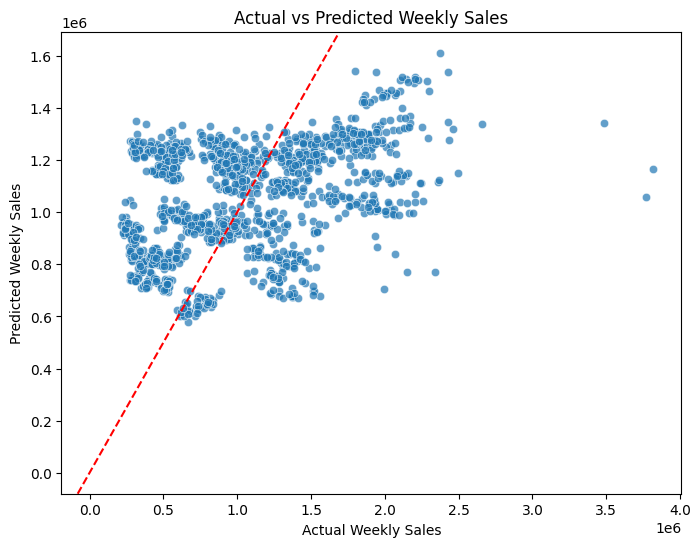

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")

# Perfect prediction line
plt.axline((0, 0), slope=1, color='red', linestyle='--')

plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9327
RMSE: 147212.1973
